# 25b · GSE135779 · scRNA_seq (pseudobulk) · where the 28 interferon response genes land

Reads `wgcna_input.rds`, `modules.rds` and `expression.rds`, and `projected_scores.rds` in `data/run_artifacts/GSE135779/`.
Writes nothing.

**Gene sets**, both from de Jesus AA et al. Distinct interferon signatures and cytokine patterns define
additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669–1682,
doi:10.1172/JCI129301, supplement:
- `genes/ifn-interferonopathy-28.txt`: the 28-gene interferon response gene score (IRG-S),
  Supplemental Figure 3B. It splits into 25 genes with a STAT1 binding site only and 3 (CXCL10, GBP1,
  SOCS1) with both STAT1 and NF-κB binding sites.
- `genes/nfkb-validation-11.txt`: 11 NF-κB targets with no STAT1, STAT2 or TYK1 binding site
  (Methods Step 2; Supplemental Figure 5). The authors use them as a control for the 3-gene subscore;
  here they are the control for the 28.

**What is reported, for each gene.** No test; a description.
1. Measured in this study, and in the WGCNA network (notebook 23/24 filters).
2. Its module (notebook 25).
3. kME with the interferon module: the Pearson correlation of the gene with the module eigengene, over
   the 33 children used to build the network (Horvath S, Dong J. Geometric interpretation of gene coexpression
   network analysis. *PLoS Comput Biol* 2008;4:e1000117, doi:10.1371/journal.pcbi.1000117).
4. r with the GSE65391 pink module projected into these samples (notebook 26b): Pearson
   correlation of the gene with the projected pink score, over the same samples. This places each gene
   against the array's interferon module, not this study's own.

**Which module is the interferon module here.** The module that holds the most of the 28 genes that
are in the network. 

In [1]:
source("../src/paths.R")
G <- "GSE135779"
w <- readRDS(art(G, "wgcna_input.rds"))
m <- readRDS(art(G, "modules.rds"))
e <- readRDS(art(G, "expression.rds"))
sub3 <- read_gene_set("ifn-interferonopathy-3-stat1-nfkb.txt")
sets <- list("IRG-28" = read_gene_set("ifn-interferonopathy-28.txt"), "NF-kB-11" = read_gene_set("nfkb-validation-11.txt"))
g <- data.frame(set = rep(names(sets), lengths(sets)), gene = unlist(sets), row.names = NULL)
g$subscore   <- ifelse(g$set == "NF-kB-11", "", ifelse(g$gene %in% sub3, "3 STAT1/NF-kB", "25 STAT1-only"))
g$measured   <- g$gene %in% rownames(e$E)
g$in_network <- g$gene %in% colnames(w$datExpr)
g$module     <- ifelse(g$in_network, unname(m$colors[g$gene]), NA)
c(samples_in_network = nrow(w$datExpr), genes_in_network = ncol(w$datExpr))

samples_in_network   genes_in_network 
                33              15353

In [2]:
irg_modules <- sort(table(g$module[g$set == "IRG-28"]), decreasing = TRUE)
irg_modules
ifn_module <- names(irg_modules)[1]
ifn_module


royalblue turquoise 
       27         1 

[1] "royalblue"

In [3]:
net <- g$gene[g$in_network]
g$kME_ifn <- NA_real_
g$kME_ifn[g$in_network] <- round(m$kME[net, paste0("ME", ifn_module)], 2)
p <- readRDS(art(G, "projected_scores.rds"))
pink <- p$scores[rownames(w$datExpr), "pink"]
g$r_array_pink <- NA_real_
g$r_array_pink[g$in_network] <- round(cor(w$datExpr[, net], pink)[, 1], 2)
g

set,gene,subscore,measured,in_network,module,kME_ifn,r_array_pink
<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>
IRG-28,DDX60,25 STAT1-only,TRUE,TRUE,royalblue,0.95,0.91
IRG-28,EPSTI1,25 STAT1-only,TRUE,TRUE,royalblue,0.88,0.83
IRG-28,HERC5,25 STAT1-only,TRUE,TRUE,royalblue,0.95,0.92
IRG-28,HERC6,25 STAT1-only,TRUE,TRUE,royalblue,0.91,0.83
IRG-28,IFI27,25 STAT1-only,TRUE,TRUE,royalblue,0.93,0.90
IRG-28,IFI44,25 STAT1-only,TRUE,TRUE,royalblue,0.90,0.90
IRG-28,IFI44L,25 STAT1-only,TRUE,TRUE,royalblue,0.85,0.83
IRG-28,IFI6,25 STAT1-only,TRUE,TRUE,royalblue,0.94,0.94
IRG-28,IFIT1,25 STAT1-only,TRUE,TRUE,royalblue,0.96,0.93


In [4]:
summ <- do.call(rbind, lapply(split(g, g$set), function(d) data.frame(
  set = d$set[1], genes = nrow(d), measured = sum(d$measured), in_network = sum(d$in_network),
  in_ifn_module = sum(d$module == ifn_module, na.rm = TRUE),
  median_kME_ifn = median(d$kME_ifn, na.rm = TRUE))))
summ$set <- factor(summ$set, names(sets)); summ[order(summ$set), ]

,set,genes,measured,in_network,in_ifn_module,median_kME_ifn
,<fct>,<int>,<int>,<int>,<int>,<dbl>
IRG-28,IRG-28,28,28,28,27,0.925
NF-kB-11,NF-kB-11,11,11,11,1,0.140


**Result.** The interferon module is royalblue. 27 of the 28 genes are in it, with kME 0.77 (CXCL10)
to 0.98 (IFIT3); median over all 28 is 0.925. The exception is SOCS1, one of the 3 STAT1/NF-κB genes:
it is in turquoise, with kME with royalblue −0.30. Against the array pink score projected into these
children, the 27 give r = 0.75 to 0.97, and SOCS1 −0.20.

Control: one of the 11 NF-κB genes, GZMB, is in royalblue (kME 0.51). The other ten are spread over
eight modules, with kME with royalblue −0.13 to 0.52; median over the 11 is 0.14.

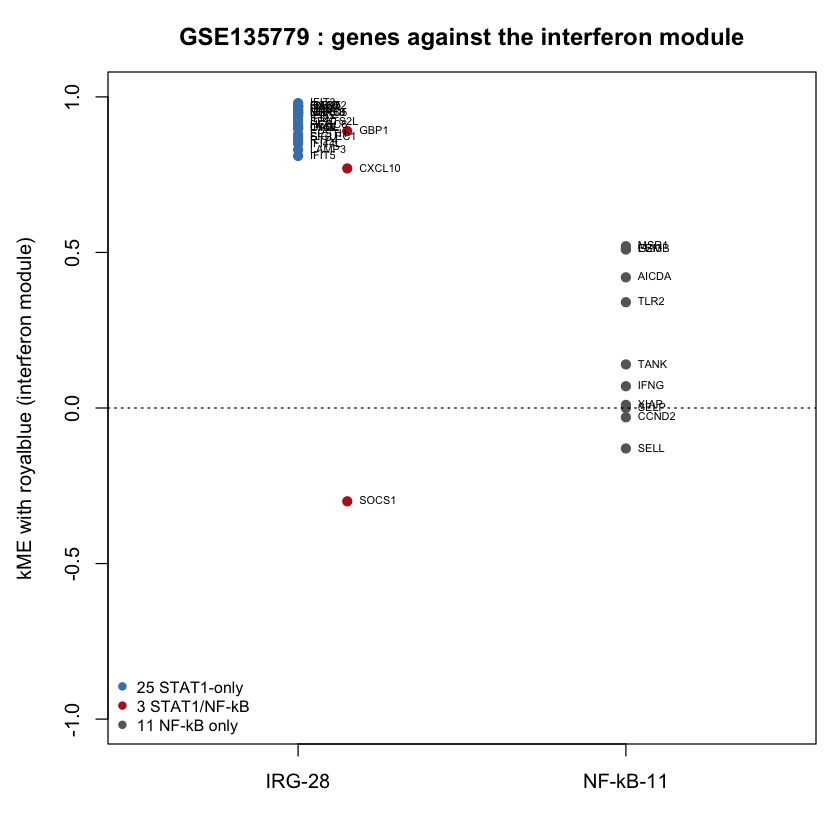

In [5]:
figure <- function() {
  d <- g[g$in_network, ]
  d$x <- as.integer(factor(d$set, names(sets))) + ifelse(d$subscore == "3 STAT1/NF-kB", 0.15, 0)
  par(mar = c(4, 4.5, 3, 1))
  plot(d$x, d$kME_ifn, xlim = c(0.5, 2.5), ylim = c(-1, 1), xaxt = "n", pch = 19,
       col = ifelse(d$set == "NF-kB-11", "grey40", ifelse(d$subscore == "3 STAT1/NF-kB", "firebrick", "steelblue")),
       xlab = "", ylab = paste0("kME with ", ifn_module, " (interferon module)"),
       main = paste(G, ": genes against the interferon module"))
  axis(1, at = 1:2, labels = names(sets)); abline(h = 0, lty = 3)
  text(d$x, d$kME_ifn, d$gene, pos = 4, cex = 0.55)
  legend("bottomleft", c("25 STAT1-only", "3 STAT1/NF-kB", "11 NF-kB only"), pch = 19,
         col = c("steelblue", "firebrick", "grey40"), bty = "n", cex = 0.8)
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig(G, "25b_interferon_genes.png"), width = 7, height = 7, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}